Author: Thomas Joyce

Class: ASTR 400B - Galaxies and Cosmology

Description: Workbook documenting Homework 7

--------------------------------------------------------------------------------------------------------------------------------

In [4]:
### Importations ###
# Numpy and Astropy
import numpy as np
import astropy.units as u
import astropy.constants as const
# Plotting
import matplotlib.pyplot as plt
# Latex Equation Display
from IPython.display import Latex
# External (must be in same directory as Homework7)
from ReadFile import Read 
from CenterOfMass import CenterOfMass
from GalaxyProfiles import MassProfile
from GalaxyMass import ComponentMass
# Subject Matter #
from OrbitIntergration import M33AnalyticOrbit

See the submitted OrbitIntergration python script for further inspection of the class and functions. For the purpose of this notebook the script will be imported. 

# Part 5: Question 1 #

In [27]:
# Initializing the class #
M33Orbit = M33AnalyticOrbit('M33IntergatedOrbit.txt')

# Using the Orbital Intergration #
M33Orbit.OrbitIntegration(0, 0.1, 10)

In [28]:
# Retrieved from HW 6 #
def ReadOrbitFile(FileName):
    ''' 
    Description: reads orbit txt file generated from OrbitCOM and saves the data
    into variables Time, Gal_pos, and Gal_vec 
    
    Inputs:
        - FileName: File name to be read in (string)
        
    Returns:
        - Time: a list of time values in Gyr (NON Astropy Quantity)
        - Gal_Pos: an array of COM position vectors for the galaxy in kpc, the data
        is formatted as Gal_Pos = [ [COM X positions], [COM Y positions], [COM Z positions] ]
        (NON Astropy Quantity)
        - Gal_Vec: an array of COM velocity vectors for the galaxy in km/s, the data
        is formatted as Gal_Vec = [ [COM X velocity], [COM Y velocity], [COM Z velocity] ]
        (NON Astropy Quantity)'''
    data = np.genfromtxt(FileName, dtype = None, names = True, skip_header = 0) # data array creation
    
    Time = data['t']
    Gal_Pos = [ data['x'], data['y'], data['z'] ]
    Gal_Vec = [ data['vx'], data['vy'], data['vz'] ]
    
    return Time, Gal_Pos, Gal_Vec
### END ReadOrbitFile

In [29]:
def RelativeSeperation(Gal1, Gal2):
    ''' 
    Description: Determines the relative seperation of a state vector for Galaxy 1 (Gal1)
    and Galaxy 2 (Gal2). This can be done with position (giving the relative position seperation) and
    with velocity (giving ht relative velocity between the two)
    
    Inputs:
        - Gal1: State vector for galaxy 1, list with indeces [x_component, y_component, z_component]
        - Gal2: State vector for galaxy 2, list with indeces [x_component, y_component, z_component]
        
    Returns:
        - SeperationMagnitude: Magnitude of the difference between the two state vectors
    '''
    
    # Computing X Seperation #
    X_sep = Gal2[0] - Gal1[0]
    
    # Computing Y Seperation #
    Y_sep = Gal2[1] - Gal1[1]
    
    # Computing Z Seperation #
    Z_sep = Gal2[2] - Gal1[2]
    
    SeperationMagnitude = np.sqrt((X_sep ** 2) + (Y_sep ** 2) + (Z_sep ** 2))
    
    return SeperationMagnitude
### END RelativeSeperation

In [33]:
def PlotRelativeSeperationComparison(Gal1_FileName, Gal2_FileName, mode):
    ''' 
    Description: Plots the relative state vector seperation of two galaxies based upon the input file names. Overplots
    the leapfrog intergration method for comparison. 
    
    Inputs:
        - Gal1_FileName: string file name for the first galaxy desired 
        - Gal2_FileName: string file name for the second galaxy desired '''
    
    # Reading Orbit Files (Filenames passed as inputs)
    G1_time, G1_pos, G1_vec = ReadOrbitFile(Gal1_FileName)
    G2_time, G2_pos, G2_vec = ReadOrbitFile(Gal2_FileName)
    
    # Determinining seperation list for plotting based upon modes #
    if mode == 'Distance':
        SepMag = []
        for index in range(0, len(G1_pos[0])): # iterating through each time step
            SepM = RelativeSeperation([G1_pos[0][index], G1_pos[1][index], G1_pos[2][index]], [G2_pos[0][index], G2_pos[1][index], G2_pos[2][index]])
            SepMag.append(SepM)
            
    if mode == 'Velocity':
        SepMag = []
        for index in range(0, len(G1_vec[0])): # iterating through each time step
            SepM = RelativeSeperation([G1_vec[0][index], G1_vec[1][index], G1_vec[2][index]], [G2_vec[0][index], G2_vec[1][index], G2_vec[2][index]])
            SepMag.append(SepM)
    
    # Determining Galxy names from filename for plotting #
    Gal1_name = Gal1_FileName[6:-4]
    Gal2_name = Gal2_FileName[6:-4]
    
    ### LeapFrog Intergration Overplotting ###
    time, RelativePositionVector, RelativeVelocityVector = ReadOrbitFile('M33IntergatedOrbit.txt')
    
    RelativePosition = np.sqrt((RelativePositionVector[0] ** 2) + (RelativePositionVector[1] ** 2) + (RelativePositionVector[2] ** 2))
    RelativeVelocity = np.sqrt((RelativeVelocityVector[0] ** 2) + (RelativeVelocityVector[1] ** 2) + (RelativeVelocityVector[2] ** 2))
    
    # Figure #
    plt.figure('Relative Seperation Plot', figsize = (6,6), dpi = 250)
    
    # Plotting #
    plt.scatter(G1_time, SepMag, marker = '.', s = 80, color = 'black', label = 'COM Propogation')
    
    if mode == 'Distance':
        plt.scatter(time, RelativePosition, marker = '.', s = 80, color = 'blue', label = 'Leapfrog')
        
    if mode == 'Velocity':
        plt.scatter(time, RelativeVelocity, marker = '.', s = 80, color = 'blue', label = 'Leapfrog')

    # Plot Formatting #
    if mode == 'Distance':
        Ylabel = 'Relative Seperation [kpc]'
        Title = 'Relative Distance Between ' + Gal1_name + ' and ' + Gal2_name
        Output = Gal1_name + '_' + Gal2_name + 'RelativeDistance.png'
    if mode == 'Velocity':
        Ylabel = 'Relative Velocity [km/s]'
        Title = 'Relative Velocity Between ' + Gal1_name + ' and ' + Gal2_name
        Output = Gal1_name + '_' + Gal2_name + 'RelativeVelocity.png'
    
    plt.xlabel('Time [Gyr]', fontsize = 15)
    plt.ylabel(Ylabel, fontsize = 15)
    plt.title(Title)
    
    plt.grid(axis = 'both', color = 'grey', linewidth = 0.7, linestyle=':')
    
    plt.legend()
    
    plt.tight_layout()
    
    # Plot Saving #
    plt.savefig(Output)
### END PlotRelativeSeperation

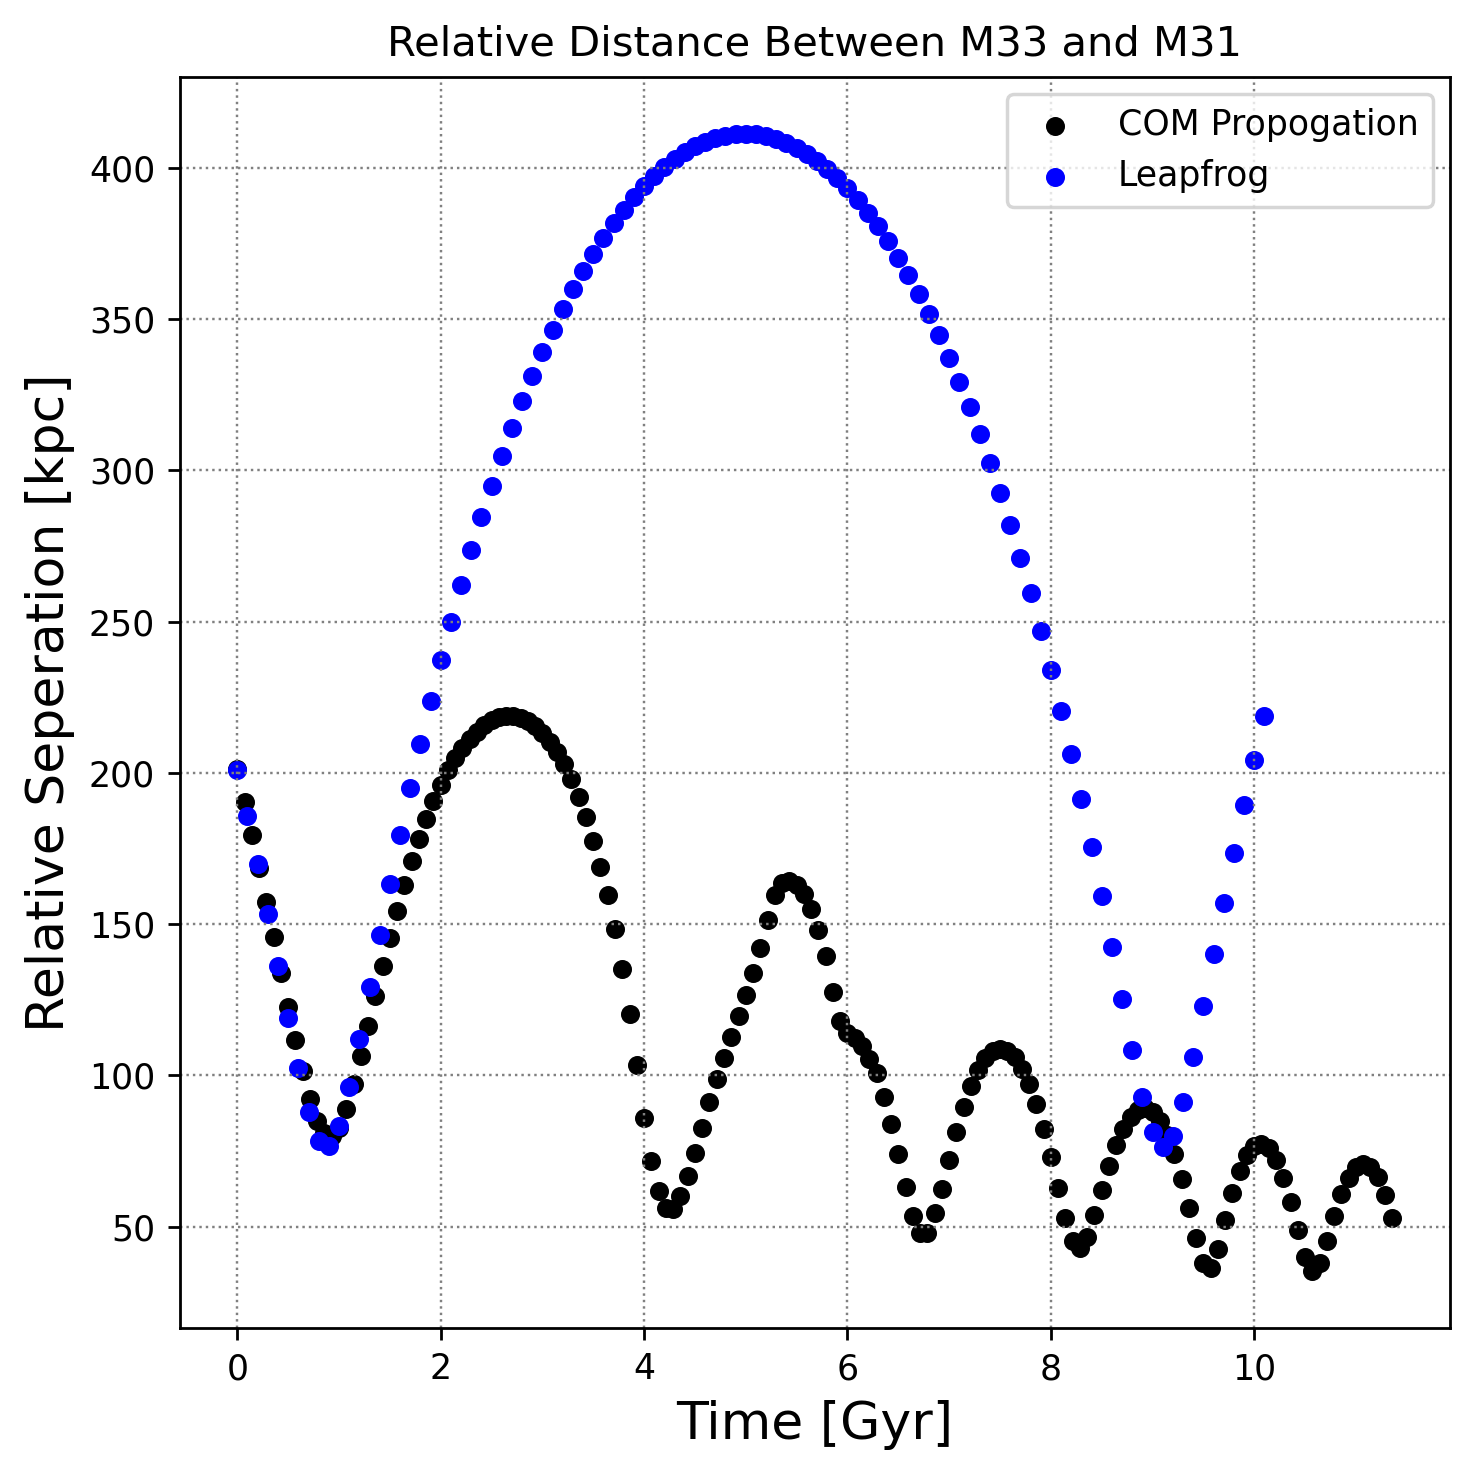

In [34]:
# Relative Seperation of M33 and M31 #
PlotRelativeSeperationComparison('Orbit_M33.txt', 'Orbit_M31.txt', 'Distance')

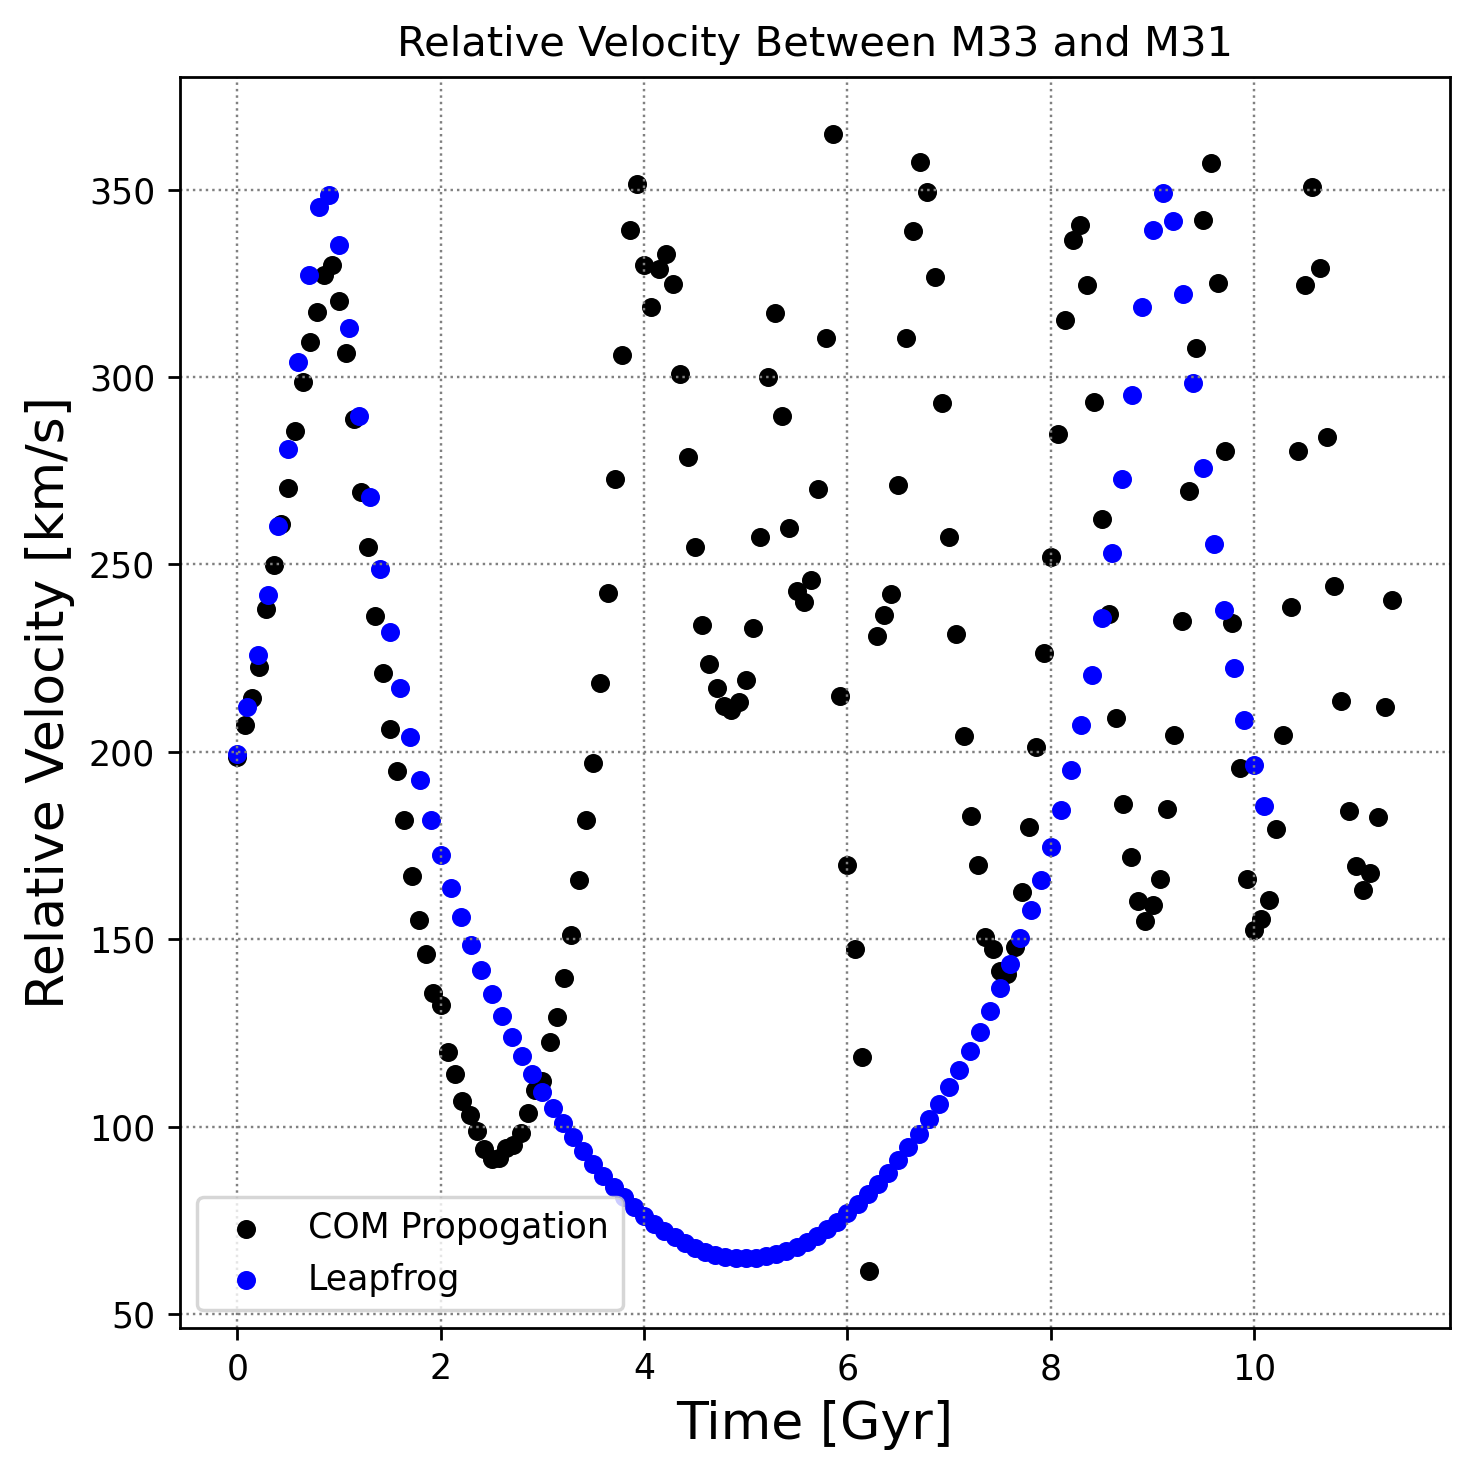

In [35]:
# Relative Velocity of M33 and M31 #
PlotRelativeSeperationComparison('Orbit_M33.txt', 'Orbit_M31.txt', 'Velocity')

# Part 5: Question 2 #

The plots actually don't match up too well, especially at higher times. The two methodlogies do align in the beginning of the time evolution from about  ~(0 - 2 Gyrs) however it quickly diverges and reconverges briefly at around 9 Gyrs. The beginning aligns well becuase dynamical friction has not yet acted intensely upon the system. The realignment at 9 Gyrs is just coincidence as M33 gets close by M31 again.   

# Part 5: Question 3 #

By using this leapfrog method we are not considering M33 to be an extended body. Here we are propogating it as just a point mass. If we assume M33 to act as a point mass out in space with no physical extension or rotation, then this would cancel out the effects of dynamical friction. Becuase M33 is a group of stars rotating as a galaxy with angular momentum, there exists dynamical friction as a result of this merging interaction, causing the orbit to decay over time as with what we see in the black. The orbit in blue just assumes a point mass, so the orbit is stable and doesn't expierence any significant decay or transfer of angular momentum. 

# Part 5: Question 3 #

Should we include the Milky Way in this calculation, we would have another significant source of gravity to consider when propogating things out. Due to this additional source of gravity we would expierence a 3 body problem, and M33 may be able to be pushed or pulled upon by this extra source of extended mass. In the current picture dynamical friction is ignored, making a near perfect keplerian-like orbital scheme. However if the Milky Way is there we would have to consider this situation as something of a restricted 3 body problem. We can use this approximation becuase MW and M31 are so much more massive than M33, and M33 is treated as a point mass falling under the correct assumptions for this solution set. 

Overall we would expect the orbit to deviate from the ideal situation we see in blue, in fact the orbit may even be more chaotic. 